# Toomre Diagram for Gaia J1644-0449 paper

The goal of this Jupyter notebook, if it wasn't obvious, is to make the Toomre diagram that will go in the discovery paper for Gaia J1644-0449. I want its color scheme to be consistent with all of the other plots so the paper is easier to follow.

I figured the best way to accomplish that was to move into a Jupyter notebook, but we'll see if that holds true.

Before I can really do anything here though, I need to generate a text file that contains the relevant kinematic quantities for the three white dwarfs of interest from the kinematics.py script. Basically I just need that one to actually have a damn header with the output so I'm not having to manually match indices.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
import matplotlib.patches as mp

start = time.time()


import spec_plot_tools as spt
import cal_params as cp
#import plot_spec as ps
#import bensby_plotting as bp
print(os.getcwd())

/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
os.chdir(target_dir)

In [3]:
kin_file='J1644_paper_kinematics.csv'
kin_table=Table.read(kin_file)

In [4]:
color_dict={
    'GaiaJ1644-0449':'r',
    'SDSSJ1330+6435':'darkviolet',
    'WDJ2356-209':'g'
}
step_dict={
    'GaiaJ1644-0449':10,
    'SDSSJ1330+6435':0.1,
    'WDJ2356-209':10
}

wd_marker='*'
met_marker='D'
met_color='#1ca1f2'
ci_size=14
ci_leg_size=10
wd_size=14
dp_alpha=1
arr_naca=[-0.4,-0.1]

star_marker='o'
pop_colors=['darkorange','brown','navy','grey'] #thin disk, thick disk, halo, in-between for Bensby plots




In [5]:
#######3error distribution variables
mc_number = 100000
percent_off = 34 #1-sigma equivalent
#############
rv_zero=0.
rv_sigma=100.
#####

def get_mc_distribution(value, error):
    error_distribution = np.random.normal(loc= value, scale = error, size = mc_number)
    #plt.hist(error_distribution)
    #plt.axvline(x=value, color='r')
    #plt.axvline(x=np.median(error_distribution), linestyle='--', color='k')
    #plt.show()
    #print('value:', value, 'error:',error, 'median:', np.median(error_distribution))
    return error_distribution


def get_errors(distribution, percent_off = percent_off):
    """
    values for the error bars on the plot
    
    Returns
    [- value, + value], so to get the points on the plot where they'd be located you do
    value - [- value] , value + [- value]
    Basically these are the width of the uncertainty range on either side.
    """
    low_bar = np.nanpercentile(distribution, 50-percent_off)
    median = np.nanmedian(distribution)
    high_bar = np.nanpercentile(distribution, 50+percent_off)
    try:
        return np.array([[median-low_bar],[high_bar-median]])
    #except astropy.units.core.UnitsError as error:
    except u.core.UnitsError as error:
        return  np.array([[median.value-low_bar],[high_bar-median.value]])
    
def test_errorbars(group_vel, group_disp, label):
    group_vel=np.array(group_vel)
    group_disp=np.array(group_disp)
    u_dist= get_mc_distribution(group_vel[0], group_disp[0])
    v_dist= get_mc_distribution(group_vel[1], group_disp[1])
    w_dist=get_mc_distribution(group_vel[2], group_disp[2])
    uw_dist= np.sqrt(v_dist**2+w_dist**2)
    
    uw_mean= np.nanmean(uw_dist)
    uw_std= np.std(uw_dist)
    print(label, 'UW', uw_mean, '+/-', uw_std)
    print('quadrature version', np.sqrt(group_vel[0]**2+group_vel[2]**2),np.sqrt(group_disp[0]**2+group_disp[2]**2))
    print(label, 'V MC', np.nanmean(v_dist), '+/-', np.std(v_dist), np.median(v_dist))
    print(label, 'V reported', group_vel[1], group_disp[1])
    #plt.hist(uw_dist)
    #plt.show()
    return [group_vel[1], group_disp[1]], [uw_mean, uw_std]



In [6]:
#Torres et al. 2019 values
thin_disc_vel=[2.52, -1.45, 2.60]
thin_disc_disp=[22.5, 17.4, 16.2]
thick_disc_vel=[-18.58,-30.03, 1.06]
thick_disc_disp=[50.4, 29.3, 33.1]
halo_vel=[-27.31, -92.29, 3.41]
halo_disp=[100.8, 67.4, 66.9]
    


def generate_toomre_diagram():
    #fig= plt.figure()
    def plot_kinematic_group(group_vel, group_disp, label, color='b', marker='o'):
        group_v, group_uw= test_errorbars(group_vel, group_disp, label)
        #plt.errorbar(group_vel[1], np.sqrt(group_vel[0]**2+group_vel[2]**2), xerr= group_disp[1], yerr= np.sqrt(group_disp[0]**2+group_disp[2]**2),label=label, color=color, marker=marker)
        plt.errorbar(group_v[0], group_uw[0], xerr= group_v[1], yerr= group_uw[1] ,label=label, marker=marker,color=color, linestyle='None')
        return
    td_v, td_uw=test_errorbars(thin_disc_vel, thin_disc_disp,'thin disk')
    plot_kinematic_group(thin_disc_vel, thin_disc_disp, 'thin disk',color=pop_colors[0], marker=star_marker )
    plot_kinematic_group(thick_disc_vel, thick_disc_disp, 'thick disk', color=pop_colors[1], marker=star_marker)
    plot_kinematic_group(halo_vel, halo_disp, 'halo',color=pop_colors[2],marker=star_marker)
    #generate 3-sigma and 5-sigma ellipse
    sig3_ellipse= mp.Ellipse((td_v[0], td_uw[0]), td_v[1]*3*2, td_uw[1]*3*2, fill=False, edgecolor='k', linestyle='--')
    sig5_ellipse= mp.Ellipse((td_v[0], td_uw[0]), td_v[1]*5*2, td_uw[1]*5*2, fill=False, edgecolor='k', linestyle='--')
    ax=plt.axes()
    ax.add_patch(sig3_ellipse)
    ax.add_patch(sig5_ellipse)
    plt.xlabel('V (km/s)')
    plt.ylabel(r'$(U^2+W^2)^{1/2}$ (km/s)')
    #plt.legend(loc='best')
    #plt.xlim(-300, 100)
    #plt.show()
    


thin disk UW 21.2465628366 +/- 11.1172191828
quadrature version 3.62082863444 27.7252592413
thin disk V MC -1.43037459873 +/- 17.3976240217 -1.41448072852
thin disk V reported -1.45 17.4
thin disk UW 21.3094893299 +/- 11.1346578083
quadrature version 3.62082863444 27.7252592413
thin disk V MC -1.46746953787 +/- 17.4786138729 -1.43766635176
thin disk V reported -1.45 17.4
thick disk UW 47.9624267163 +/- 23.6867313766
quadrature version 18.6102122503 60.2973465419
thick disk V MC -29.9626808405 +/- 29.2734296782 -30.028613434
thick disk V reported -30.03 29.3
halo UW 119.947456883 +/- 56.2158300065
quadrature version 27.5220675095 120.980370309
halo V MC -92.1829549091 +/- 67.402148851 -92.2330618935
halo V reported -92.29 67.4


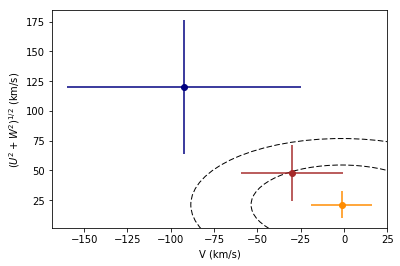

In [7]:
generate_toomre_diagram()
plt.show()

thin disk UW 21.2536368897 +/- 11.0777178916
quadrature version 3.62082863444 27.7252592413
thin disk V MC -1.38037235777 +/- 17.3686600901 -1.39053764899
thin disk V reported -1.45 17.4
thin disk UW 21.2038708567 +/- 11.1169293267
quadrature version 3.62082863444 27.7252592413
thin disk V MC -1.4555196129 +/- 17.3921813314 -1.41239710385
thin disk V reported -1.45 17.4
thick disk UW 47.995547782 +/- 23.6612667414
quadrature version 18.6102122503 60.2973465419
thick disk V MC -30.1758860464 +/- 29.2862934094 -30.1689382181
thick disk V reported -30.03 29.3
halo UW 119.478384578 +/- 56.3714500713
quadrature version 27.5220675095 120.980370309
halo V MC -92.0384562182 +/- 67.3582315112 -92.0144822778
halo V reported -92.29 67.4


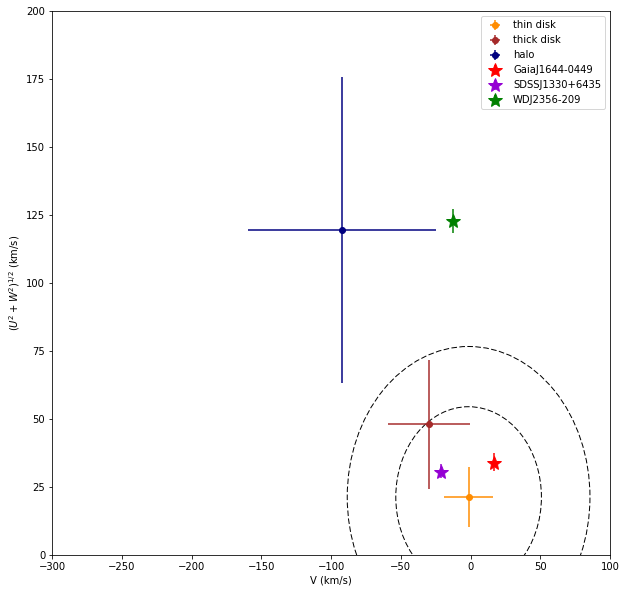

In [12]:
plt.figure(figsize=(10,10))
generate_toomre_diagram()
for row in kin_table:
    plt.errorbar(row['v'],row['uw2'],xerr=[[row['v_err_lo']],[row['v_err_hi']]],yerr=[[row['uw2_err_lo']],[row['uw2_err_hi']]],label=row['name'],marker=wd_marker, color=color_dict[row['name']],markersize=wd_size, linestyle='None')
plt.legend(loc='best')
plt.xlim(-300, 100)
plt.ylim(0,200)
plt.show()